In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [3]:
import numpy as np
import polars as pl

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [4]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], add_coulomb=True)
df = mp.load()

2026-04-22 15:12:36.378 | INFO     | src.datasets:load:1355 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-22 15:12:37.064 | INFO     | src.datasets:_add_descriptors:1719 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-22 15:12:37.065 | INFO     | src.datasets:_add_descriptors:1753 - Calculating max atoms for Coulomb Matrix padding...
2026-04-22 15:12:37.317 | INFO     | src.datasets:_add_descriptors:1800 - Computing Coulomb Matrix chunk 0 (0 to 1000)...
2026-04-22 15:12:37.766 | INFO     | src.datasets:_add_descriptors:1800 - Computing Coulomb Matrix chunk 1 (1000 to 2000)...
2026-04-22 15:12:38.241 | INFO     | src.datasets:_add_descriptors:1800 - Computing Coulomb Matrix chunk 2 (2000 to 3000)...
2026-04-22 15:12:38.739 | INFO     | src.datasets:_add_descriptors:1800 - Computing Coulomb Matrix chunk 3 (3000 to 4000)...
2026-04-22 15:12:39.522 | INFO     | src.datasets:_add

In [5]:
dist_matrix = mp.get_distance_matrix(
    descriptor="coulomb",
    dist_type="euclidean",
    pca_components=4,
    force_calculate=True,
)

2026-04-22 15:12:43.793 | INFO     | src.datasets:get_distance_matrix:1988 - Applying PCA to reduce 'coulomb_matrix' to 4 dimensions.
2026-04-22 15:12:44.161 | INFO     | src.datasets:get_distance_matrix:1994 - PCA kept 87.82% of the variance for 'coulomb_matrix'.
2026-04-22 15:12:44.161 | INFO     | src.datasets:get_distance_matrix:1996 - PCA reduced 'coulomb_matrix' dimensions from 10000 to 4
2026-04-22 15:12:44.174 | INFO     | src.datasets:get_distance_matrix:2014 - Calculating distance matrix for coulomb_matrix using euclidean distance.
2026-04-22 15:12:44.320 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/Materials Project/dist_coulomb_matrix_euclidean_pca4.npy


# Hierarchical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_47396/1475297569.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2, 3, 4], dtype=int32), array([3955,  952,   81,   12]))


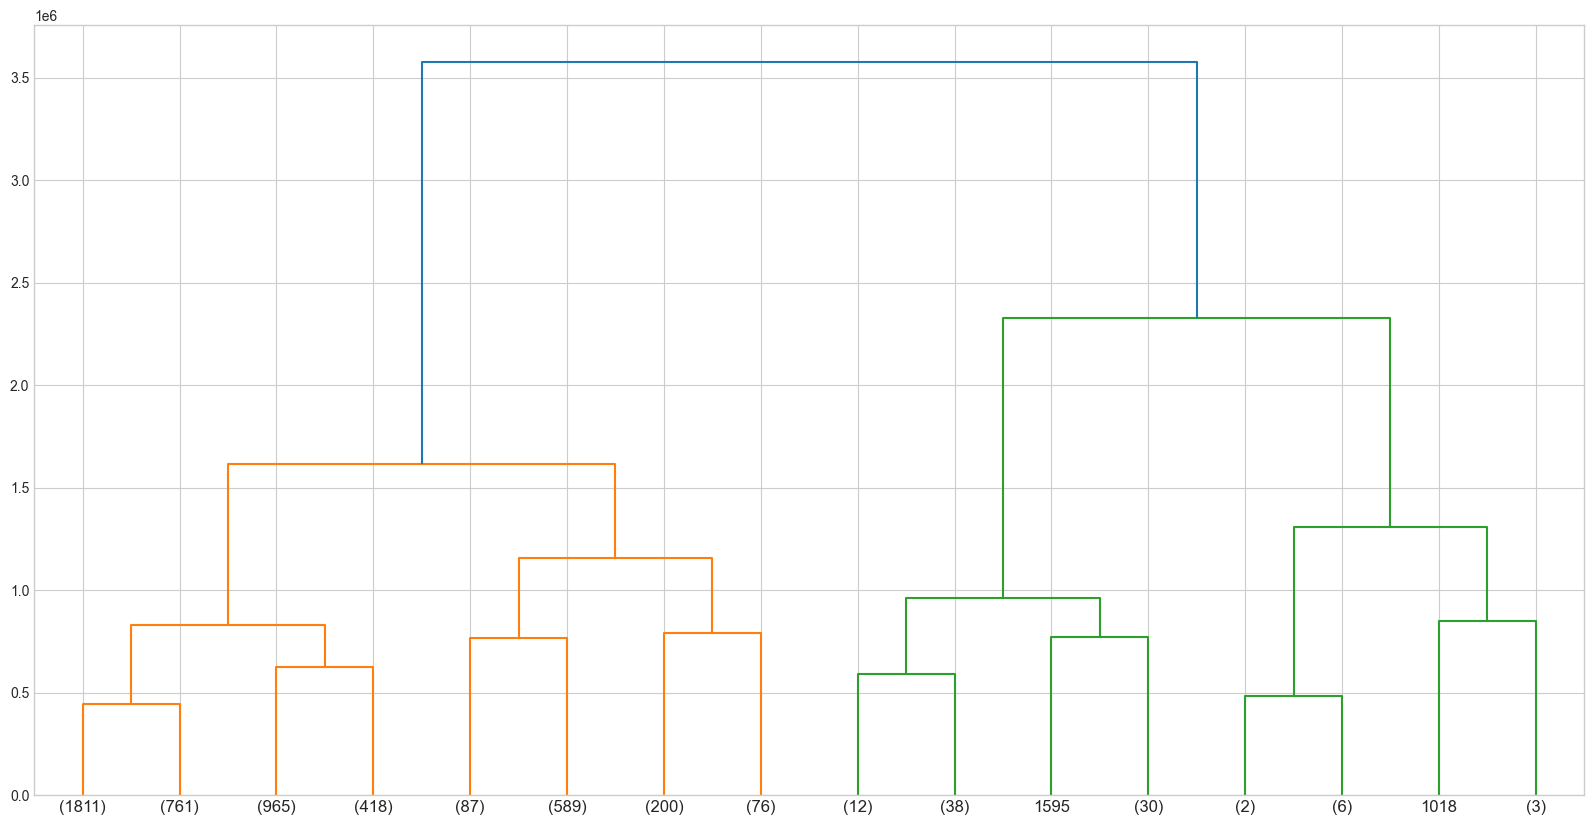

In [17]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=3, truncate_mode='level')
labels_hier = fcluster(link, t=1.4e6, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [18]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (4, 29)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬─────────┬─────────┬─────────┬─────────┬─────────┬───────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b       ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume    ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_km ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_anonymized_formula ┆ top_anonymized_formula_pct │
│ ---         ┆ -

In [8]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-22 15:12:45.141 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_hierarchical_projection.png


{'coords': array([[ 957793.83373506, -420405.94594409],
        [-232456.00959239, -347092.54274315],
        [-613439.95221161,  334101.99685904],
        ...,
        [-598907.59877614,  364676.71789643],
        [ 172290.59751035, -380457.96479458],
        [ 435495.47544103, -418144.13879404]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/coulomb/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/coulomb'),
 'clustering_method': 'hierarchical'}

In [9]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [10]:
model_km = KMedoids(n_clusters=10, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint64), array([ 436,  240,  107,  400,  481, 1560,  329,  223,  564,  660]))


In [11]:
average_numeric_by_cluster(df, "labels_km")

shape: (10, 29)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬────────────────────────┬────────────────────┬────────────────────────┬─────────────────────┬─────────────────┬─────────────────────┬────────────────────────────┬────────────────────────┬────────────────────────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ pct_metal ┆ unique_crystal_systems ┆ top_crystal_system ┆ top_crystal_system_pct ┆ unique_space_groups ┆ top_space_group ┆ top_space_group_pct ┆ unique_anonymized_formulas ┆ top_anonymized_formula ┆ top_anonymized_formula_pct │
│ ---       ┆ ---   

labels_km,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,pct_metal,unique_crystal_systems,top_crystal_system,top_crystal_system_pct,unique_space_groups,top_space_group,top_space_group_pct,unique_anonymized_formulas,top_anonymized_formula,top_anonymized_formula_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,436,1.363257,-21.727013,-1.126865,0.418538,8.890219,6.205645,6.587828,9.008343,85.814815,86.091904,88.857343,276.203312,15.428899,0.059735,2.433551,2.679172,2.0,71.100917,7,"""Orthorhombic""",27.752294,81,"""Amm2""",5.963303,128,"""AB2C3D3""",6.192661
1,240,1.400292,-13.84083,-1.149277,0.617808,6.65315,8.528092,9.976135,13.565219,90.387187,90.793151,90.947874,896.212777,39.195833,0.035256,2.541657,2.760344,1.95,52.5,7,"""Orthorhombic""",31.25,88,"""Pnma""",12.083333,161,"""AB2""",3.75
2,107,1.209159,-25.90122,-0.886016,0.250913,10.677415,8.927171,9.892534,11.219257,87.87795,88.184799,92.800927,840.859129,39.523364,0.035358,2.587245,2.789913,0.121495,72.897196,7,"""Orthorhombic""",28.037383,52,"""Pnma""",9.345794,81,"""ABC4""",3.738318
3,400,1.4794,-13.154273,-1.258492,0.550043,6.360027,7.20449,8.062103,10.429428,89.346526,89.14932,95.346524,452.077695,21.78,0.051877,2.500533,2.762997,2.0,59.25,7,"""Orthorhombic""",29.5,90,"""Pnma""",7.5,191,"""AB2C4""",3.5
4,481,1.394449,-19.033901,-1.105708,0.39981,7.992492,5.927212,6.001858,7.610855,82.370137,82.300098,80.024606,192.6906,10.453222,0.058589,2.49599,2.696683,2.0,71.101871,7,"""Cubic""",25.571726,65,"""Fm-3m""",17.879418,113,"""ABC2""",17.671518
5,1560,1.879468,-7.360326,-1.552303,0.699133,3.827544,6.419759,6.858746,9.260307,86.425024,87.743349,87.761217,356.105717,27.153205,0.132051,2.020445,2.321296,2.0,47.564103,7,"""Monoclinic""",26.474359,133,"""P1""",13.653846,480,"""ABC2""",3.974359
6,329,1.320973,-24.103958,-1.13246,0.403672,9.69649,6.887952,7.336973,8.998489,88.690709,88.100928,92.876793,356.005263,19.525836,0.040339,2.456757,2.677884,2.0,70.516717,7,"""Orthorhombic""",25.531915,84,"""Amm2""",6.990881,150,"""AB2C3D3""",4.559271
7,223,1.267265,-24.314038,-0.996844,0.3657,9.761071,7.7005,8.566356,9.877658,90.35116,91.212958,91.357258,530.127791,27.596413,0.039398,2.520317,2.756355,1.237668,75.336323,7,"""Monoclinic""",30.044843,63,"""P1""",8.071749,141,"""AB2C5""",4.035874
8,564,1.636738,-10.286237,-1.363328,0.675648,5.212213,7.228593,7.706366,9.753836,88.78751,90.040729,90.293747,445.309844,25.842199,0.061085,2.265658,2.567305,2.0,52.12766,7,"""Monoclinic""",27.304965,109,"""P2_1/c""",8.333333,249,"""ABC3""",4.255319


In [12]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [13]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-22 15:12:49.832 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_kmedoids_projection.png


{'coords': array([[ 957793.83373506, -420405.94594409],
        [-232456.00959239, -347092.54274315],
        [-613439.95221161,  334101.99685904],
        ...,
        [-598907.59877614,  364676.71789643],
        [ 172290.59751035, -380457.96479458],
        [ 435495.47544103, -418144.13879404]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/coulomb/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/coulomb'),
 'clustering_method': 'kmedoids'}

# Spectral

In [14]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

KeyboardInterrupt: 

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

NameError: name 'labels_spectral' is not defined

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 20)
┌─────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬────────┬─────────┬─────────┬──────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┐
│ labels_spectral ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c      ┆ alpha   ┆ beta    ┆ gamma    ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km │
│ ---             ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---      ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       │
│ i32             ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64      ┆ f6

# DBSCAN

In [ ]:
model_db = DBSCAN(
    eps=7500,
    min_samples=5,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5]), array([ 172, 4756,   42,    7,    6,    8,    9]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="coulomb",
    distance_metric="euclidean",
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-19 14:06:06.701 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/euclidean/coulomb/pca_dbscan_projection.png


{'coords': array([[2800442.63967447,  756369.6823298 ],
        [  48568.4980794 , -326827.80857034],
        [-609746.51810078,  345730.93704956],
        ...,
        [-355393.16155332, -171267.3980381 ],
        [2286565.81470132,  396153.62667518],
        [-157155.44091623,  -94446.57618272]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/materials_project/clustering/euclidean/coulomb/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/euclidean/coulomb'),
 'clustering_method': 'dbscan'}

In [ ]:
average_numeric_by_cluster(df, "labels_db")

shape: (11, 22)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬─────────┬─────────┬─────────┬─────────┬──────────┬──────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬─────────────────┬───────────────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a       ┆ b       ┆ c       ┆ alpha   ┆ beta     ┆ gamma    ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ labels_spectral ┆ labels_kmeans_raw │
│ ---       ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       ┆ ---             ┆ ---               │
│ i64       ┆ u32   ┆ f64         ┆ f64             ┆ f64   

# KMeans on Raw Embeddings

In [ ]:
from sklearn.decomposition import PCA
X = np.array(df["coulomb_matrix"].to_list(), dtype=np.float32)
pca = PCA(n_components=4)
X = pca.fit_transform(X)

kmeans_raw = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")

shape: (6, 21)
┌───────────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┐
│ labels_kmeans_raw ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal │
│ ---               ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       ┆ ---       │
│ i32               ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    

labels_kmeans_raw,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,1127,1.462289,-15.357988,-1.195896,0.48172,7.250105,5.869343,6.061825,8.061484,84.158394,84.305335,84.582874,216.734188,11.972493,0.084957,2.443999,2.703292,2.0,0.017746,70.186335
1,315,1.231365,-25.292602,-0.964053,0.295952,9.933522,7.593197,8.270002,9.993003,90.602551,90.562946,93.824273,503.416783,25.149206,0.033063,2.569308,2.778839,1.695238,1.0,79.047619
2,2248,1.808581,-8.06312,-1.481597,0.845961,4.252105,6.492373,6.922955,8.788828,85.847216,86.86647,87.5408,353.139131,25.105427,0.111091,2.083013,2.39822,2.0,1.8621,48.309609
3,641,1.549251,-12.799116,-1.285209,0.767241,6.167187,8.118135,8.906263,11.254611,88.992097,89.963378,93.293617,655.599515,30.842434,0.037635,2.462927,2.743731,2.0,0.928237,49.765991
4,569,1.331371,-22.804023,-1.07688,0.443418,9.054328,6.596384,7.033204,8.968662,84.807013,85.36339,92.552455,318.123401,17.630931,0.046274,2.460624,2.701295,2.0,0.977153,72.58348
5,100,1.1684,-25.477963,-0.887861,0.201496,10.660682,9.386537,9.886112,12.952253,88.494598,88.950935,92.766832,969.686963,43.19,0.024547,2.638048,2.8027,0.29,1.0,76.0


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans_raw, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…